# Model Analysis
An in-depth comparison of four models, supplemented with visualizations. The document was created to evaluate and compare which of these models performed best for generating our ground truth
Analyzed models:
- docling
- llamaindex
- chandra
- hunyuan

In [13]:
from pathlib import Path
import json
import difflib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML, Markdown

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

### Load models

In [14]:
try:
    from google.colab import files as colab_files
    print("Upload model output files:")
    uploaded = colab_files.upload()
    texts = {
        fname.replace(".md", ""): content.decode("utf-8")
        for fname, content in uploaded.items()
    }
except ImportError:
    folder = "data/models_outputs"
    texts = {
        Path(p).stem.replace("_output", ""): Path(p).read_text(encoding="utf-8")
        for p in Path(folder).glob("*.md")
    }

print(f"\n{len(texts)} models loaded.\n")

Upload model output files:


Saving deepseek_ocr2_output.md to deepseek_ocr2_output.md
Saving docling_output.md to docling_output.md
Saving hunyuan_output.md to hunyuan_output.md
Saving llamaindex.md to llamaindex.md

4 models loaded.



### Basic Statistics

In [15]:
stats_data = []
for name, text in texts.items():
    stats_data.append({
        'Model': name,
        'Lines': text.count('\n'),
        'Words': len(text.split()),
        'Characters': len(text)
    })

stats_df = pd.DataFrame(stats_data)

print("\n Basic Statistics:\n")
display(stats_df.style.format({
    'Lines': '{:,}',
    'Words': '{:,}',
    'Characters': '{:,}'
}))


 Basic Statistics:



,Model,Lines,Words,Characters
0,deepseek_ocr2_output,"2,824","25,008","213,761"
1,docling_output,"3,354","26,707","222,246"
2,hunyuan_output,"3,404","29,437","196,419"
3,llamaindex,"2,860","30,393","204,704"


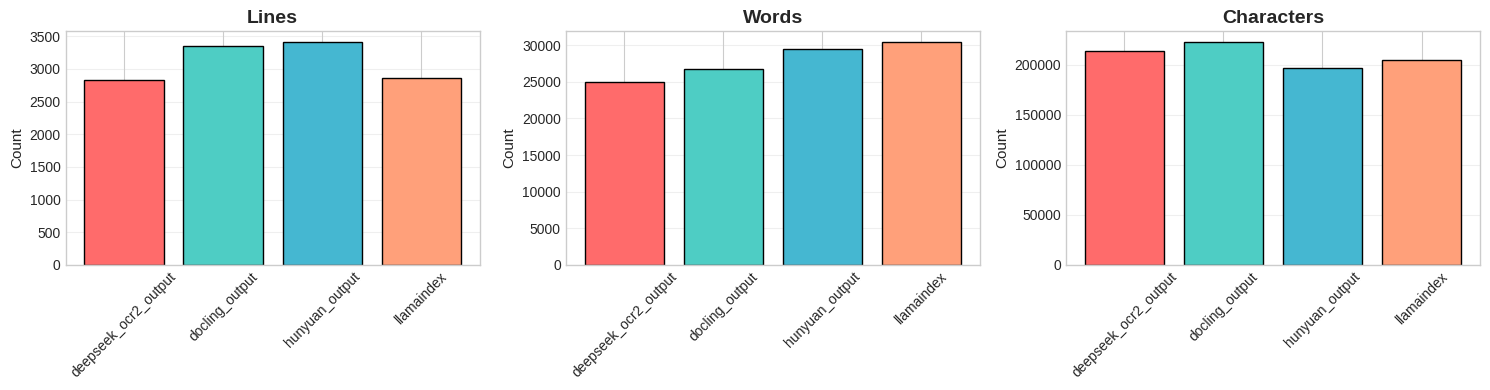

In [16]:
# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for i, col in enumerate(['Lines', 'Words', 'Characters']):
    axes[i].bar(stats_df['Model'], stats_df[col], color=colors, edgecolor='black')
    axes[i].set_title(col, fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Count', fontsize=11)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Similarity Matrix

In [17]:
model_names = list(texts.keys())
n = len(model_names)

# Calculate similarity
similarity_matrix = [[0.0 for _ in range(n)] for _ in range(n)]

for i, name1 in enumerate(model_names):
    for j, name2 in enumerate(model_names):
        if i == j:
            similarity_matrix[i][j] = 1.0
        else:
            sim = difflib.SequenceMatcher(None, texts[name1], texts[name2]).ratio()
            similarity_matrix[i][j] = sim

sim_df = pd.DataFrame(similarity_matrix, index=model_names, columns=model_names)

print("\n SIMILARITY MATRIX\n")
display(sim_df.style.format("{:.1%}").background_gradient(
    cmap='RdYlGn',
    vmin=0.3,
    vmax=1.0
))


 SIMILARITY MATRIX



,deepseek_ocr2_output,docling_output,hunyuan_output,llamaindex
deepseek_ocr2_output,100.0%,36.9%,60.8%,66.6%
docling_output,51.1%,100.0%,42.1%,22.9%
hunyuan_output,62.8%,40.8%,100.0%,14.3%
llamaindex,66.2%,42.3%,66.7%,100.0%


### Average Similarity (Consensus)

In [18]:
avg_similarities = {}
for name in model_names:
    sims = [sim_df.loc[name, other] for other in model_names if other != name]
    avg_similarities[name] = sum(sims) / len(sims)

avg_df = pd.DataFrame([
    {'Model': name, 'Average Similarity': sim}
    for name, sim in sorted(avg_similarities.items(), key=lambda x: x[1], reverse=True)
])

print("\n AVERAGE SIMILARITY (Consensus)\n")
display(avg_df.style.format({'Average Similarity': '{:.1%}'}).bar(
    subset=['Average Similarity'],
    color="#A17B1A",
    vmin=0,
    vmax=1
))

best_model = avg_df.iloc[0]['Model']
best_score = avg_df.iloc[0]['Average Similarity']

display(Markdown(f"### Highest consensus: **{best_model}** ({best_score:.1%})"))


 AVERAGE SIMILARITY (Consensus)



,Model,Average Similarity
0,llamaindex,58.4%
1,deepseek_ocr2_output,54.7%
2,hunyuan_output,39.3%
3,docling_output,38.7%


### Highest consensus: **llamaindex** (58.4%)

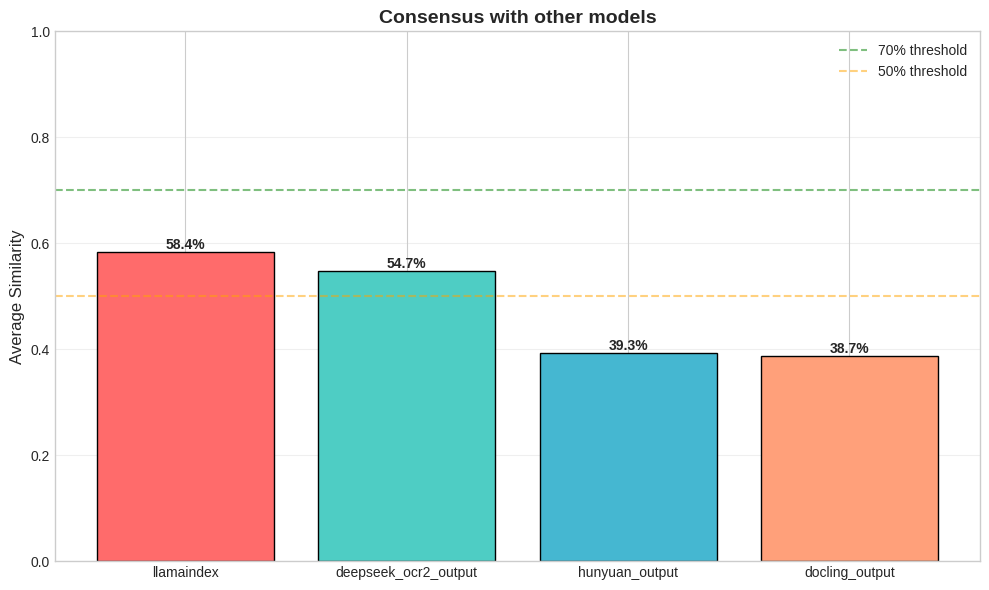

In [19]:
# Chart
plt.figure(figsize=(10, 6))
bars = plt.bar(avg_df['Model'], avg_df['Average Similarity'], color=colors, edgecolor='black')
plt.ylabel('Average Similarity', fontsize=12)
plt.title('Consensus with other models', fontsize=14, fontweight='bold')
plt.axhline(y=0.7, color='green', linestyle='--', alpha=0.5, label='70% threshold')
plt.axhline(y=0.5, color='orange', linestyle='--', alpha=0.5, label='50% threshold')
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1%}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### Edit Distance Analysis

In [20]:
# Select baseline (highest consensus)
baseline_name = best_model
baseline_text = texts[baseline_name]

print(f"\nUsing {baseline_name} as baseline for edit distance\n")

edit_data = []
for name, text in texts.items():
    if name == baseline_name:
        continue

    sm = difflib.SequenceMatcher(None, baseline_text, text)

    insertions = deletions = substitutions = 0
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == 'insert':
            insertions += (j2 - j1)
        elif tag == 'delete':
            deletions += (i2 - i1)
        elif tag == 'replace':
            substitutions += max(i2 - i1, j2 - j1)

    total = insertions + deletions + substitutions
    edit_rate = total / len(baseline_text)

    edit_data.append({
        'Model': name,
        'Insertions': insertions,
        'Deletions': deletions,
        'Substitutions': substitutions,
        'Total': total,
        'Edit Rate': edit_rate
    })

edit_df = pd.DataFrame(edit_data)

print(f" EDIT DISTANCE (vs {baseline_name})\n")
display(edit_df.style.format({
    'Insertions': '{:,}',
    'Deletions': '{:,}',
    'Substitutions': '{:,}',
    'Total': '{:,}',
    'Edit Rate': '{:.2%}'
}).background_gradient(subset=['Edit Rate'], cmap='RdYlGn_r'))


Using llamaindex as baseline for edit distance

 EDIT DISTANCE (vs llamaindex)



,Model,Insertions,Deletions,Substitutions,Total,Edit Rate
0,deepseek_ocr2_output,"23,031","21,511","84,563","129,105",63.07%
1,docling_output,"40,723","29,116","155,742","225,581",110.20%
2,hunyuan_output,"32,075","16,815","78,771","127,661",62.36%


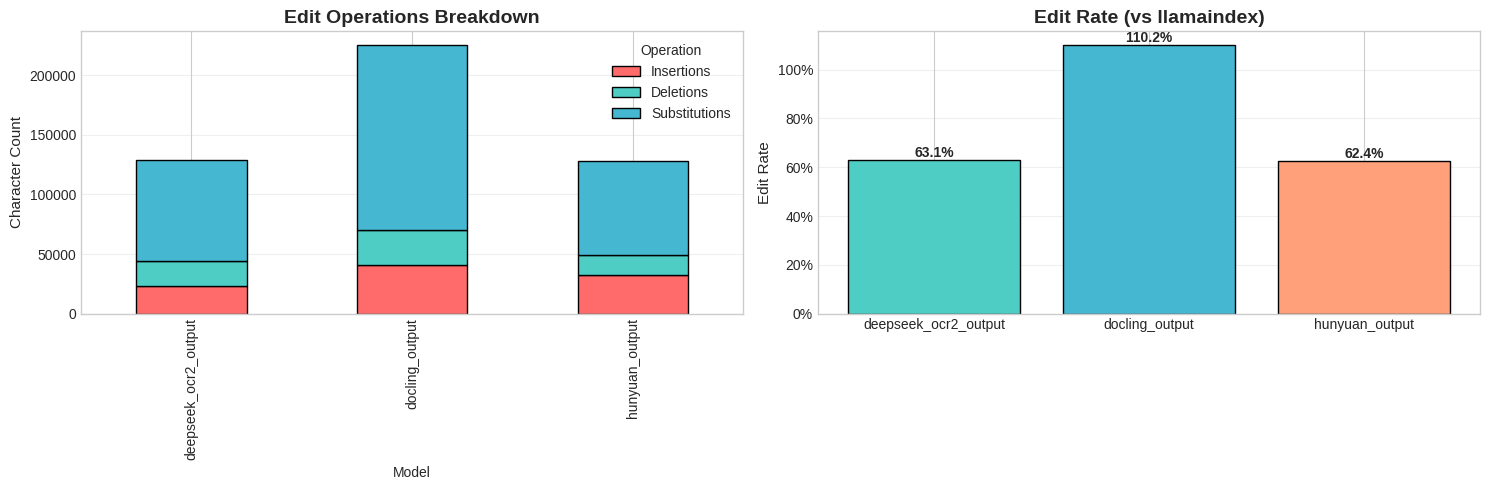

In [21]:
# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Stacked bar
edit_df.set_index('Model')[['Insertions', 'Deletions', 'Substitutions']].plot(
    kind='bar',
    stacked=True,
    ax=ax1,
    color=['#FF6B6B', '#4ECDC4', '#45B7D1'],
    edgecolor='black'
)
ax1.set_title('Edit Operations Breakdown', fontsize=14, fontweight='bold')
ax1.set_ylabel('Character Count', fontsize=11)
ax1.legend(title='Operation')
ax1.grid(axis='y', alpha=0.3)

# Edit rate
bars = ax2.bar(edit_df['Model'], edit_df['Edit Rate'],
               color=['#4ECDC4', '#45B7D1', '#FFA07A'], edgecolor='black')
ax2.set_title(f'Edit Rate (vs {baseline_name})', fontsize=14, fontweight='bold')
ax2.set_ylabel('Edit Rate', fontsize=11)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
ax2.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1%}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


### Exampel of differences

In [22]:
def show_differences(text1, text2, name1, name2, max_examples=5):
    lines1 = text1.splitlines()
    lines2 = text2.splitlines()

    differ = difflib.Differ()
    diff = list(differ.compare(lines1[:200], lines2[:200]))

    print(f"\n{'='*80}")
    print(f"{name1} vs {name2}")
    print(f"{'='*80}\n")

    count = 0
    i = 0

    while i < len(diff) and count < max_examples:
        line = diff[i]
        if line.startswith('- '):
            print(f"- Line {i+1}:")
            print(f"   {name1:15s}: {line[2:100]}")
            if i + 1 < len(diff) and diff[i + 1].startswith('+ '):
                print(f"   {name2:15s}: {diff[i + 1][2:100]}")
                i += 1
            print()
            count += 1
        i += 1

# Show differences for each model vs baseline
for name in texts.keys():
    if name != baseline_name:
        show_differences(baseline_text, texts[name], baseline_name, name, max_examples=3)


llamaindex vs deepseek_ocr2_output

- Line 3:
   llamaindex     : # Årsredovisning 2022

- Line 8:
   llamaindex     : 

- Line 9:
   llamaindex     : **FLEXQUBE**


llamaindex vs docling_output

- Line 3:
   llamaindex     : # Årsredovisning 2022

- Line 20:
   llamaindex     : **FLEXQUBE**

- Line 29:
   llamaindex     : # Det här är FlexQube
   docling_output : ## Det här är FlexQube


llamaindex vs hunyuan_output

- Line 5:
   llamaindex     : **FLEXQUBE**
   hunyuan_output : ## FLEXQUBE

- Line 30:
   llamaindex     : # Översikt
   hunyuan_output : ## Innehåll

- Line 33:
   llamaindex     : * Vår historia ...................................................................................

